# 🤖 Practical 01 - Advanced Expert Rule-Based System

This notebook implements an interactive **Career Advisor Expert System** with user interface widgets and a graph decision tree visualization.

### 1. Import Required Libraries

In [1]:
import os
import sys

def add_graphviz_to_path():
    curr = os.getcwd()
    for _ in range(5):
        potential_path = os.path.join(curr, 'graphviz', 'Graphviz-12.0.0-win64', 'bin')
        if os.path.exists(potential_path):
            os.environ['PATH'] += os.pathsep + potential_path
            break
        curr = os.path.dirname(curr)
add_graphviz_to_path()

import ipywidgets as widgets
from IPython.display import display, Markdown
import graphviz

### 2. Expert System Logic

Define the career advisory rule mapping based on user stream choice.

In [2]:
def career_advisor(stream):
    stream = stream.lower()
    if stream == "science":
        return "🔬 You can pursue **Engineering, Medicine, or Research**."
    elif stream == "commerce":
        return "💼 You can pursue **CA, B.Com, or MBA**."
    elif stream == "arts":
        return "🎭 You can pursue **Journalism, Literature, or Civil Services**."
    else:
        return "⚠️ Please select a valid stream."

### 3. Interactive UI Interface

Setup ipywidgets to gather input from user and display responses dynamically.

In [3]:
# Dropdown widget
dropdown = widgets.Dropdown(
    options=['Science', 'Commerce', 'Arts'],
    description='Choose Stream:',
    style={'description_width': 'initial'}
)

# Button widget
button = widgets.Button(description="Get Career Advice", button_style='info')

# Output area
output = widgets.Output()

# Button click event
def on_button_clicked(b):
    with output:
        output.clear_output()
        result = career_advisor(dropdown.value)
        display(Markdown(result))

button.on_click(on_button_clicked)

display(Markdown("## 🎓 Career Advisor Expert System"))
display(dropdown, button, output)

## 🎓 Career Advisor Expert System

Dropdown(description='Choose Stream:', options=('Science', 'Commerce', 'Arts'), style=DescriptionStyle(descrip…

Button(button_style='info', description='Get Career Advice', style=ButtonStyle())

Output()

### 4. Decision Tree Visualization

Visualize the expert system rules as a directed graph.

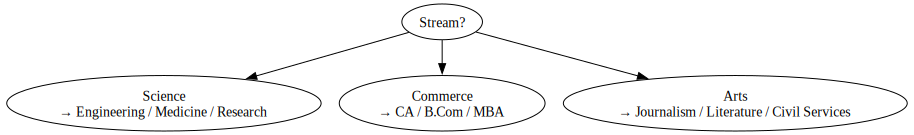

In [4]:
dot = graphviz.Digraph(comment="Career Advisor Expert System")
dot.node('A', 'Stream?')
dot.node('B', 'Science\n→ Engineering / Medicine / Research')
dot.node('C', 'Commerce\n→ CA / B.Com / MBA')
dot.node('D', 'Arts\n→ Journalism / Literature / Civil Services')

dot.edges(['AB', 'AC', 'AD'])
display(dot)